# Imports

In [9]:
from data_loader import load_conll2003
from preprocessing import build_vocab, sentences_to_indices
from dataset import SkipGramDataset
from model import Word2VecSGNS
from trainer import train
import numpy as np
import matplotlib.pyplot as plt

print("All modules imported successfully.")

All modules imported successfully.


# Load dataset

In [10]:
print("Loading CoNLL2003 dataset...")

sentences = load_conll2003()

print("Dataset loaded successfully.")
print("Total number of sentences:", len(sentences))

print("\nExample sentence:")
print(sentences[0])

Loading CoNLL2003 dataset...
Dataset loaded successfully.
Total number of sentences: 20744

Example sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


# Build vocab

In [11]:
print("Building vocabulary...")

vocab, word2idx, idx2word, counter = build_vocab(sentences)

indexed_sentences = sentences_to_indices(sentences, word2idx)

vocab_size = len(vocab)

print("Vocabulary built successfully.")
print("Vocabulary size:", vocab_size)

print("\nSample words in vocabulary:")
print(vocab[:10])

print("\nExample word → index mapping:")
for w in vocab[:5]:
    print(w, "->", word2idx[w])

Building vocabulary...
Vocabulary built successfully.
Vocabulary size: 30289

Sample words in vocabulary:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.', 'Peter']

Example word → index mapping:
EU -> 0
rejects -> 1
German -> 2
call -> 3
to -> 4


# Create dataset

In [12]:
print("Creating Skip-Gram dataset...")

dataset = SkipGramDataset(indexed_sentences, window_size=2)

print("Dataset created successfully.")
print("Number of training pairs:", len(dataset))

print("\nExample training pairs (target, context):")

for i in range(5):
    target, context = dataset[i]
    print(
        idx2word[target],
        "->",
        idx2word[context]
    )

Creating Skip-Gram dataset...
Dataset created successfully.
Number of training pairs: 1081662

Example training pairs (target, context):
EU -> rejects
EU -> German
rejects -> EU
rejects -> German
rejects -> call


# Create model

In [13]:
embedding_dim = 100

print("Initializing Word2Vec SGNS model...")

model = Word2VecSGNS(vocab_size, embedding_dim)

print("Model initialized.")
print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)

print("\nShape of input embedding matrix:", model.W_in.shape)
print("Shape of output embedding matrix:", model.W_out.shape)

Initializing Word2Vec SGNS model...
Model initialized.
Vocabulary size: 30289
Embedding dimension: 100

Shape of input embedding matrix: (30289, 100)
Shape of output embedding matrix: (30289, 100)


# Train model

In [14]:
losses = train(
    model,
    dataset,
    vocab_size,
    epochs=20,
    lr=0.025,
    neg_samples=5
)

print("Training finished.")

Epoch 1 | Loss: 2.4532
Epoch 2 | Loss: 1.5860
Epoch 3 | Loss: 1.3726
Epoch 4 | Loss: 1.2560
Epoch 5 | Loss: 1.1779
Epoch 6 | Loss: 1.1155
Epoch 7 | Loss: 1.0615
Epoch 8 | Loss: 1.0158
Epoch 9 | Loss: 0.9732
Epoch 10 | Loss: 0.9359
Epoch 11 | Loss: 0.9023
Epoch 12 | Loss: 0.8692
Epoch 13 | Loss: 0.8378
Epoch 14 | Loss: 0.8093
Epoch 15 | Loss: 0.7808
Epoch 16 | Loss: 0.7557
Epoch 17 | Loss: 0.7309
Epoch 18 | Loss: 0.7061
Epoch 19 | Loss: 0.6853
Epoch 20 | Loss: 0.6641
Training finished.


# Plot 

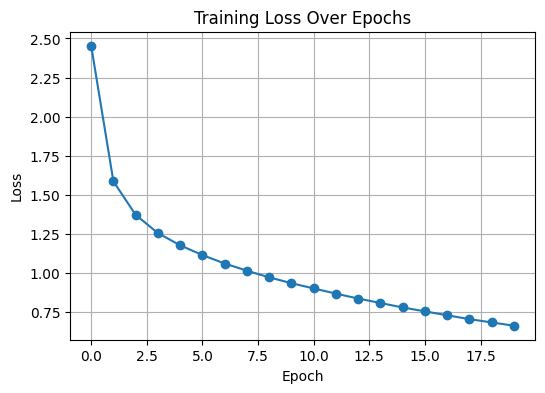

In [15]:
plt.figure(figsize=(6,4))

plt.plot(losses, marker='o')

plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

# Similarity Test

In [79]:
def most_similar(word, topk=5):

    if word not in word2idx:
        print("Word not in vocabulary")
        return

    idx = word2idx[word]
    vec = model.W_in[idx]

    sims = []

    for i in range(len(vocab)):

        other_vec = model.W_in[i]

        similarity = np.dot(vec, other_vec) / (
            np.linalg.norm(vec) * np.linalg.norm(other_vec) + 1e-9
        )

        sims.append((idx2word[i], similarity))

    sims = sorted(sims, key=lambda x: x[1], reverse=True)

    return sims[1:topk+1]


# ---- percent ----
print("\nMost similar words to 'price':\n")

results = most_similar("price")

for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")


# ---- year ----
print("\nMost similar words to 'tournament':\n")

results = most_similar("tournament")

for i, (word, score) in enumerate(results, 1):
    print(f"{i}. {word} -> {score:.4f}")


Most similar words to 'price':

1. short-term -> 0.7133
2. discount -> 0.6931
3. capacity -> 0.6914
4. tin -> 0.6884
5. 105.07 -> 0.6808

Most similar words to 'tournament':

1. championships -> 0.8253
2. Hamlet -> 0.7895
3. badminton -> 0.7807
4. basketball -> 0.7775
5. two-man -> 0.7761
